In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [46]:
path = "../data/abu_dhabi_2021_comparison.csv"
df = pd.read_csv(path)

print(df.head())
print(df["Source"].unique())
print(df.describe())

   LapDistanceNorm       Speed  Throttle  Brake  Time_seconds Source  \
0         0.000000  240.000000     100.0    0.0      0.121000    HAM   
1         0.001001  240.000000     100.0    0.0      0.121000    HAM   
2         0.002002  240.868338     100.0    0.0      0.155734    HAM   
3         0.003003  242.778117     100.0    0.0      0.232125    HAM   
4         0.004004  244.687896     100.0    0.0      0.308516    HAM   

   Time_from_start  
0         0.000000  
1         0.000000  
2         0.034734  
3         0.111125  
4         0.187516  
['HAM' 'VER']
       LapDistanceNorm        Speed     Throttle        Brake  Time_seconds  \
count      2000.000000  2000.000000  2000.000000  2000.000000   2000.000000   
mean          0.500000   248.187371    83.344122     0.120680     39.473659   
std           0.289036    59.021975    33.510476     0.316338     23.434956   
min           0.000000    71.632254     0.000000     0.000000      0.030000   
25%           0.250000   210.182

In [47]:
pilots = {p: df[df["Source"] == p] for p in df["Source"].unique()}
print(pilots.keys())

dict_keys(['HAM', 'VER'])


In [48]:
for name, data in pilots.items():
    print(f"\n{name}:")
    print(f" Min: {data['LapDistanceNorm'].min():.3f}")
    print(f" Max: {data['LapDistanceNorm'].max():.3f}")
    print(f" Puntos: {len(data)}")
    print(f" NaH en Speed: {data['Speed'].isna().sum()}")


HAM:
 Min: 0.000
 Max: 1.000
 Puntos: 1000
 NaH en Speed: 0

VER:
 Min: 0.000
 Max: 1.000
 Puntos: 1000
 NaH en Speed: 0


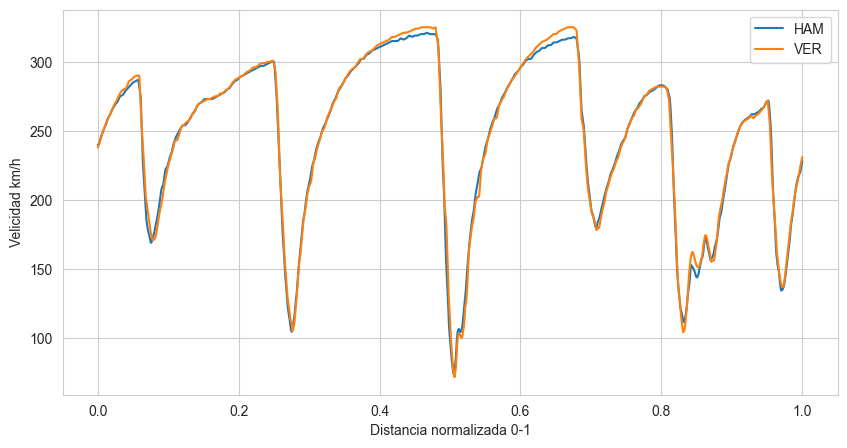

In [49]:
plt.figure()

for name, data in pilots.items():
    plt.plot(data["LapDistanceNorm"], data["Speed"], label=name)

plt.xlabel("Distancia normalizada 0-1")
plt.ylabel("Velicidad km/h")
plt.legend()
plt.show()

In [50]:
print("✅ Validación completada:")
print("- Distancia normalizada correctamente")
print("- Misma cantidad de puntos tras interpolación")
print("- Dataset listo para análisis o visualización interactiva (Dash)")

✅ Validación completada:
- Distancia normalizada correctamente
- Misma cantidad de puntos tras interpolación
- Dataset listo para análisis o visualización interactiva (Dash)


In [53]:
hamilton_times = pilots['HAM']['Time_from_start'].values
verstappen_times = pilots['VER']['Time_from_start'].values

diferencia_tiempos = hamilton_times - verstappen_times

print(f"📈 Diferencia máxima Hamilton vs Verstappen: {diferencia_tiempos.max():.3f}s")
print(f"📉 Diferencia mínima Hamilton vs Verstappen: {diferencia_tiempos.min():.3f}s")

# Donde Hamilton es más lento/más rápido
max_diferencia_idx = np.argmax(np.abs(diferencia_tiempos))
print(f"📍 Mayor diferencia en punto {max_diferencia_idx}: {diferencia_tiempos[max_diferencia_idx]:.3f}s")

📈 Diferencia máxima Hamilton vs Verstappen: 0.309s
📉 Diferencia mínima Hamilton vs Verstappen: -0.091s
📍 Mayor diferencia en punto 504: 0.309s


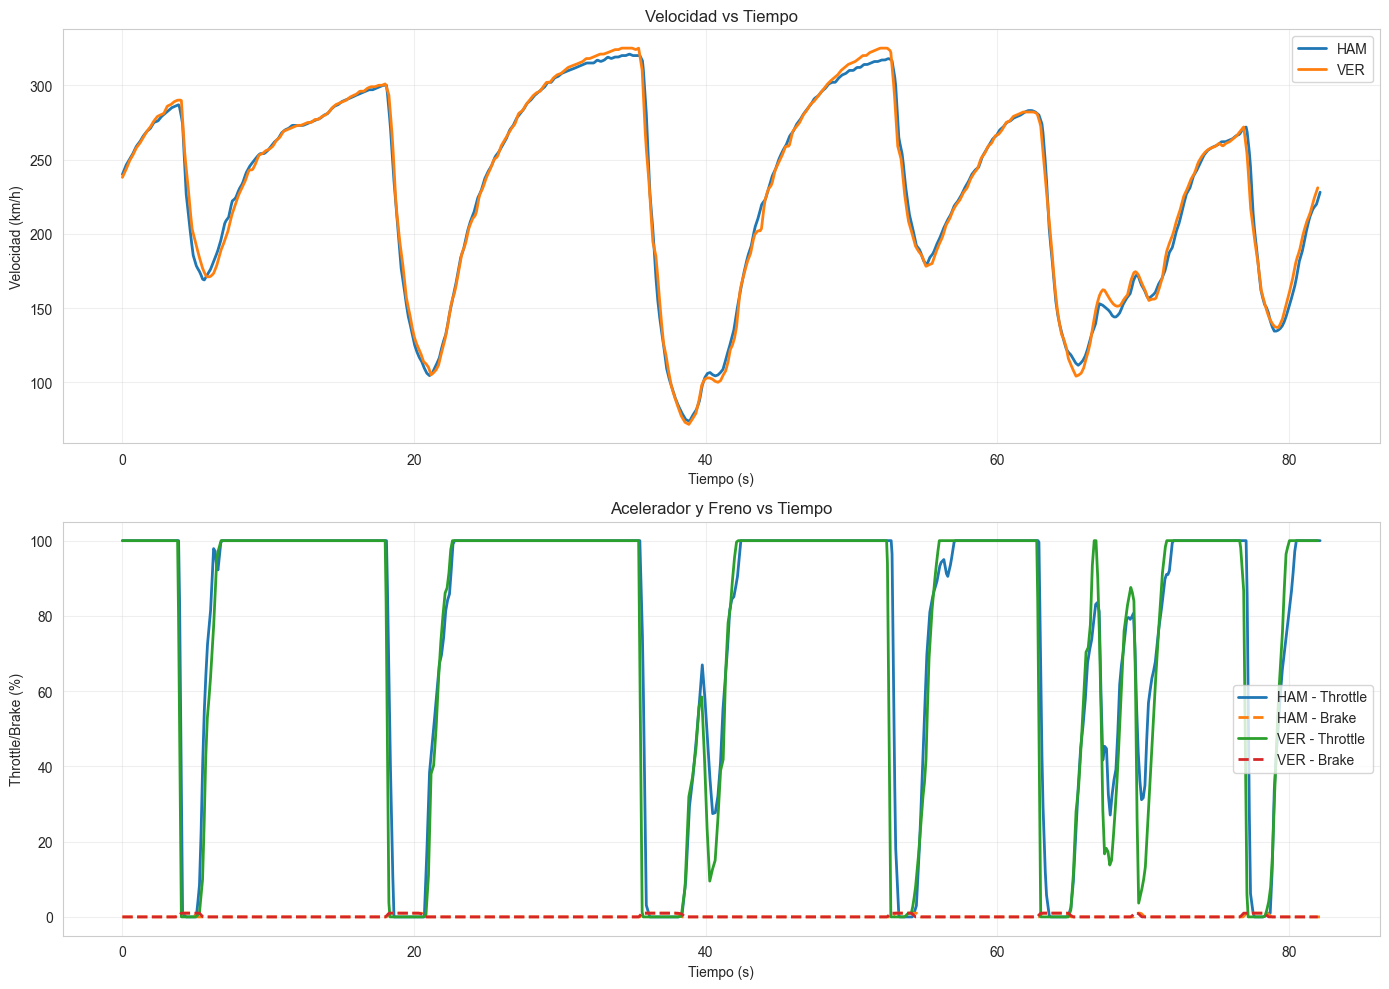

In [57]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1: Velocidad vs Tiempo
for name, data in pilots.items():
    ax1.plot(data["Time_from_start"], data["Speed"], label=name, linewidth=2)

ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Velocidad (km/h)")
ax1.set_title("Velocidad vs Tiempo")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Throttle y Brake vs Tiempo
for name, data in pilots.items():
    ax2.plot(data["Time_from_start"], data["Throttle"], 
             label=f'{name} - Throttle', linewidth=2, linestyle='-')
    ax2.plot(data["Time_from_start"], data["Brake"], 
             label=f'{name} - Brake', linewidth=2, linestyle='--')

ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("Throttle/Brake (%)")
ax2.set_title("Acelerador y Freno vs Tiempo")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()